# Assignment: Detection of Pool Balls & POV Warp for Table Top View

**Work assembled by:**
- Alejandro Gonçalves (202205564)
- Francisca Mihalache (202206022)
- João Sousa ()
- Rafael Pacheco ()

**Year:** 2025/2026


## Table of Contents

1. [Introduction](#1-introduction)
2. [Libraries & Frameworks](#2-libraries--frameworks)
    - 2.1. [Global Variables](#21-global-variables)
3. [Loading Images](#3-loading-images)
4. [Creating Cloth Mask](#4-creating-cloth-mask)
5. [Circle Detection](#5-circle-detection)
    - 5.1. [Test ball detection on the sample image](#51-test-ball-detection-on-the-sample-image)
    - 5.2. [Debug Maps and Image Enhancement](#52-debug-maps-and-image-enhancement)
6. [Ball Identification](#6-ball-identification)
    - 6.1. [Test ball identification on the sample image](#61-test-ball-identification-on-the-sample-image)
7. [Ground Truth Generation](#7-ground-truth-generation)
8. [Bounding Box Generation](#8-bounding-box-generation)
9. [Evaluation Metrics](#9-evaluation-metrics)


### 1. Introduction
[[go back to the top]](#table-of-contents)

This notebook presents a computer vision pipeline for detecting and identifying pool (billiard) balls on a table, producing a top-down (bird's eye) perspective warp.

The main challenge consists of reliably locating the billiard table's playing surface, detecting all balls present on it, and correctly identifying each ball by its number, colour, and type (solid or striped). The approach follows three main stages:

1. **Cloth Mask** — We use colour segmentation in HSV space to isolate the green or blue playing surface, filtering out the surrounding environment.
2. **Ball Detection** — Using the Hough Circle Transform on the masked region, we detect circular objects that correspond to the billiard balls.
3. **Ball Identification** — Each detected circle is analysed using colour histograms and white-pixel ratios to assign a ball number.

All image processing is performed using **OpenCV** and **NumPy**, with **Matplotlib** used for visualisation. No additional libraries are required.


### 2. Libraries & Frameworks

[[go back to the top]](#table-of-contents)


Utils file includes every necessary function and framework for this entire notebook.

In [8]:
from utils import *
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### 2.1. Global Variables
[[go back to the topic]](#2-libraries--frameworks)

In [9]:
DATA_DIR = "8-Ball Pool/train"

### 3. Loading Images

[[go back to the top]](#table-of-contents)


In [10]:
image_paths = sorted(glob.glob(os.path.join(DATA_DIR, "*.png")))
print(f"Detected {len(image_paths)} imgs")

Detected 171 imgs


### 4. Creating Cloth Mask
[[go back to the top]](#table-of-contents)

In order to optimize object detection, we decided to first mask the image to only entail the region of interest, which is the table's cloth. It's usually bright blue, but the whole dataset also has some green cloth tables, and we also wanted to prepare for possible changes. To make this a robust method, we took advantage of HSV color space to detect regions with color ranges in either blue or green, in combination with edge/corner detection filters.


In [11]:
def segment_table(img):
    # Enable hsv
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Detect blue cloth (Hue ~90-130) OR green cloth (Hue ~35-85)
    blue_mask = cv2.inRange(hsv, np.array([90, 80, 50]), np.array([130, 255, 255]))
    green_mask = cv2.inRange(hsv, np.array([35, 80, 50]), np.array([85, 255, 255]))
    mask = cv2.bitwise_or(blue_mask, green_mask)

    # Find the biggest contour -> most likely to be table
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    table_contour = max(contours, key=cv2.contourArea)

    # Approximates to 4 corners
    epsilon = 0.02 * cv2.arcLength(table_contour, True)
    approx = cv2.approxPolyDP(table_contour, epsilon, True)

    # If we don't get exactly 4 points, assumes shape 
    # closest to a 4-sided polygon
    if len(approx) == 4: corners = approx.reshape(4, 2).astype(np.float32)
    else:
        rect = cv2.minAreaRect(table_contour)
        corners = cv2.boxPoints(rect).astype(np.float32)

    # Order corners & create mask
    corners = order_corners(corners)
    clean_mask = np.zeros(img.shape[:2], dtype=np.uint8)
    cv2.fillPoly(clean_mask, [corners.astype(np.int32)], 255)

    return clean_mask, corners

Let's visualize the mask and detected corners to make sure it works.

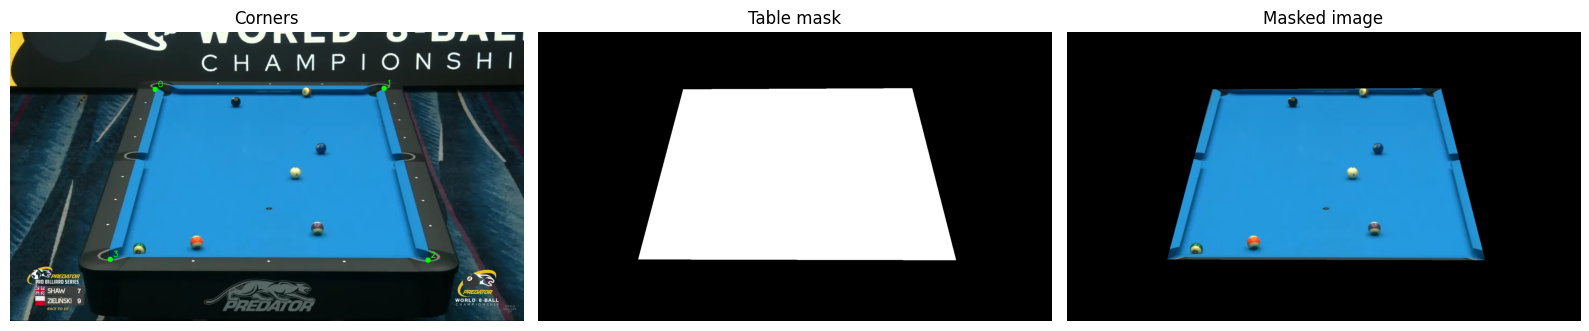

In [12]:
sample_img = cv2.imread(random.choice(image_paths))
mask, corners = segment_table(sample_img)

# Draws corners
vis = sample_img.copy()
if corners is not None:
    for i, c in enumerate(corners):
        cv2.circle(vis, tuple(c.astype(int)), 10, (0, 255, 0), -1)
        cv2.putText(vis, str(i), tuple(c.astype(int) + [10, -10]),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

# Show corners, mask and cropped image
masked_img = cv2.bitwise_and(sample_img, sample_img, mask=mask)
show([vis, mask, masked_img], ["Corners", "Table mask", "Masked image"])

Device: cpu
Total samples: 171
Ball count range: 2 - 16
Train: 136  Val: 35
Epoch   1/50 | Train MSE: 107.191 | Val MSE: 112.497 | Val MAE: 9.555
  -> Saved best model (MAE=9.555)
Epoch   2/50 | Train MSE: 46.771 | Val MSE: 60.605 | Val MAE: 6.395
  -> Saved best model (MAE=6.395)
Epoch   3/50 | Train MSE: 34.195 | Val MSE: 37.971 | Val MAE: 5.368
  -> Saved best model (MAE=5.368)
Epoch   4/50 | Train MSE: 24.778 | Val MSE: 27.067 | Val MAE: 4.652
  -> Saved best model (MAE=4.652)
Epoch   5/50 | Train MSE: 22.242 | Val MSE: 20.232 | Val MAE: 3.992
  -> Saved best model (MAE=3.992)
Epoch   6/50 | Train MSE: 20.150 | Val MSE: 17.524 | Val MAE: 3.633
  -> Saved best model (MAE=3.633)
Epoch   7/50 | Train MSE: 20.925 | Val MSE: 19.753 | Val MAE: 3.833
Epoch   8/50 | Train MSE: 17.649 | Val MSE: 15.565 | Val MAE: 3.317
  -> Saved best model (MAE=3.317)
Epoch   9/50 | Train MSE: 16.522 | Val MSE: 16.469 | Val MAE: 3.502
Epoch  10/50 | Train MSE: 16.965 | Val MSE: 14.720 | Val MAE: 3.096
  ->

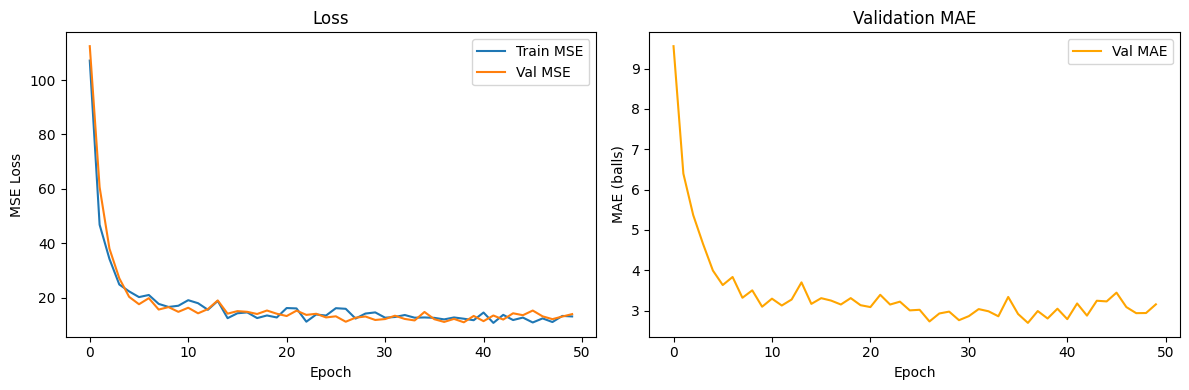

In [15]:
"""
Ball count regression using EfficientNet-B0 fine-tuning.

Pipeline:
  1. Extract ball counts from COCO JSON (exclude Dots, category_id=3)
  2. Load masked images (table cloth mask applied)
  3. Fine-tune EfficientNet-B0 with a regression head (single output)
  4. Train with MSE loss, evaluate with MAE
"""

import json
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# ── Config ────────────────────────────────────────────────────────────────────
COCO_JSON    = "8-Ball Pool/train/_annotations_labeled.coco.json"
IMAGES_DIR   = "8-Ball Pool/train"
DOT_CAT_ID   = 3
BALL_CAT_IDS = {1, 2, 4, 5}   # Black, Cue, Solid, Striped

IMG_SIZE     = 224
BATCH_SIZE   = 8
EPOCHS       = 50
LR           = 1e-3
FREEZE_BACKBONE = True        # only train the head initially
VAL_SPLIT    = 0.2
SEED         = 42

SAVE_PATH    = "ball_count_efficientnet.pth"
# ──────────────────────────────────────────────────────────────────────────────


# ── Table segmentation (from segment_table.py) ────────────────────────────────
def order_corners(corners):
    """Order corners: TL, TR, BR, BL."""
    pts = np.array(corners, dtype=np.float32)
    s   = pts.sum(axis=1)
    d   = np.diff(pts, axis=1).ravel()
    return np.array([pts[np.argmin(s)], pts[np.argmin(d)],
                     pts[np.argmax(s)], pts[np.argmax(d)]], dtype=np.float32)


def segment_table(img, erode_px=20):
    """Return (mask, corners) for the table cloth region."""
    hsv        = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    blue_mask  = cv2.inRange(hsv, np.array([90, 80, 50]),  np.array([130, 255, 255]))
    green_mask = cv2.inRange(hsv, np.array([35, 80, 50]),  np.array([85,  255, 255]))
    mask       = cv2.bitwise_or(blue_mask, green_mask)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return np.ones(img.shape[:2], dtype=np.uint8) * 255, None

    table_contour = max(contours, key=cv2.contourArea)
    epsilon       = 0.02 * cv2.arcLength(table_contour, True)
    approx        = cv2.approxPolyDP(table_contour, epsilon, True)

    if len(approx) == 4:
        corners = approx.reshape(4, 2).astype(np.float32)
    else:
        rect    = cv2.minAreaRect(table_contour)
        corners = cv2.boxPoints(rect).astype(np.float32)

    corners    = order_corners(corners)
    clean_mask = np.zeros(img.shape[:2], dtype=np.uint8)
    cv2.fillPoly(clean_mask, [corners.astype(np.int32)], 255)

    if erode_px > 0:
        kernel     = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (erode_px * 2, erode_px * 2))
        clean_mask = cv2.erode(clean_mask, kernel, iterations=1)

    return clean_mask, corners


def apply_table_mask(img):
    """Apply table mask to image, black out everything outside."""
    mask, _ = segment_table(img)
    masked   = cv2.bitwise_and(img, img, mask=mask)
    return masked
# ──────────────────────────────────────────────────────────────────────────────


def extract_labels(coco_json):
    """
    Extract ball counts per image from COCO JSON.
    Counts all annotations except Dots (category_id=3).
    Returns dict: {file_name -> count}
    """
    with open(coco_json, "r") as f:
        coco = json.load(f)

    images_by_id = {img["id"]: img["file_name"] for img in coco["images"]}

    counts = {img["file_name"]: 0 for img in coco["images"]}
    for ann in coco["annotations"]:
        if ann["category_id"] in BALL_CAT_IDS:
            fname = images_by_id[ann["image_id"]]
            counts[fname] += 1

    return counts


class BallCountDataset(Dataset):
    def __init__(self, samples, images_dir, transform=None):
        """
        samples: list of (file_name, count)
        """
        self.samples    = samples
        self.images_dir = images_dir
        self.transform  = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        fname, count = self.samples[idx]
        img_path     = os.path.join(self.images_dir, fname)

        img = cv2.imread(img_path)
        if img is None:
            # Return blank image if not found
            img = np.zeros((224, 224, 3), dtype=np.uint8)
        else:
            img = apply_table_mask(img)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transform:
            from PIL import Image
            img = self.transform(Image.fromarray(img))

        label = torch.tensor(float(count), dtype=torch.float32)
        return img, label


def build_model(freeze_backbone=True):
    """EfficientNet-B0 with regression head (single output)."""
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Replace classifier with regression head
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, 64),
        nn.ReLU(),
        nn.Linear(64, 1)
    )
    return model


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        preds = model(imgs).squeeze(1)
        loss  = criterion(preds, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(imgs)
    return total_loss / len(loader.dataset)


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_mae  = 0.0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds        = model(imgs).squeeze(1)
            total_loss  += criterion(preds, labels).item() * len(imgs)
            total_mae   += torch.abs(preds - labels).sum().item()
    n = len(loader.dataset)
    return total_loss / n, total_mae / n


def main():
    torch.manual_seed(SEED)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")

    # Build dataset
    counts  = extract_labels(COCO_JSON)
    samples = [(fname, count) for fname, count in counts.items()]
    print(f"Total samples: {len(samples)}")
    print(f"Ball count range: {min(c for _,c in samples)} - {max(c for _,c in samples)}")

    train_samples, val_samples = train_test_split(
        samples, test_size=VAL_SPLIT, random_state=SEED
    )
    print(f"Train: {len(train_samples)}  Val: {len(val_samples)}")

    train_tf = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    val_tf = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

    train_ds = BallCountDataset(train_samples, IMAGES_DIR, train_tf)
    val_ds   = BallCountDataset(val_samples,   IMAGES_DIR, val_tf)
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
    val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    model     = build_model(freeze_backbone=FREEZE_BACKBONE).to(device)
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=LR
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5
    )
    criterion = nn.MSELoss()

    train_losses, val_losses, val_maes = [], [], []
    best_mae = float("inf")

    for epoch in range(1, EPOCHS + 1):
        train_loss         = train_epoch(model, train_dl, optimizer, criterion, device)
        val_loss, val_mae  = eval_epoch(model, val_dl, criterion, device)
        scheduler.step(val_loss)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_maes.append(val_mae)

        print(f"Epoch {epoch:3d}/{EPOCHS} | "
              f"Train MSE: {train_loss:.3f} | "
              f"Val MSE: {val_loss:.3f} | "
              f"Val MAE: {val_mae:.3f}")

        if val_mae < best_mae:
            best_mae = val_mae
            torch.save(model.state_dict(), SAVE_PATH)
            print(f"  -> Saved best model (MAE={best_mae:.3f})")

    print(f"\nBest Val MAE: {best_mae:.3f}")

    # Plot training curves
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(train_losses, label="Train MSE")
    ax1.plot(val_losses,   label="Val MSE")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("MSE Loss")
    ax1.legend()
    ax1.set_title("Loss")

    ax2.plot(val_maes, label="Val MAE", color="orange")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("MAE (balls)")
    ax2.legend()
    ax2.set_title("Validation MAE")

    plt.tight_layout()
    plt.savefig("training_curves.png")
    plt.show()


if __name__ == "__main__":
    main()

Device: cpu
Total samples: 171
Ball count range: 2 - 16
Train: 136  Val: 26  Test: 9
Epoch   1/50 | Train MSE: 107.180 | Val MSE: 100.575 | Val MAE: 9.412
  -> Saved best model (MAE=9.412)
Epoch   2/50 | Train MSE: 47.252 | Val MSE: 32.482 | Val MAE: 4.540
  -> Saved best model (MAE=4.540)
Epoch   3/50 | Train MSE: 32.461 | Val MSE: 33.571 | Val MAE: 5.154
Epoch   4/50 | Train MSE: 18.361 | Val MSE: 23.122 | Val MAE: 4.109
  -> Saved best model (MAE=4.109)
Epoch   5/50 | Train MSE: 21.980 | Val MSE: 22.744 | Val MAE: 3.965
  -> Saved best model (MAE=3.965)
Epoch   6/50 | Train MSE: 21.062 | Val MSE: 25.221 | Val MAE: 4.269
Epoch   7/50 | Train MSE: 18.402 | Val MSE: 19.652 | Val MAE: 3.629
  -> Saved best model (MAE=3.629)
Epoch   8/50 | Train MSE: 17.958 | Val MSE: 23.866 | Val MAE: 3.955
Epoch   9/50 | Train MSE: 19.371 | Val MSE: 25.258 | Val MAE: 3.956
Epoch  10/50 | Train MSE: 15.570 | Val MSE: 24.055 | Val MAE: 3.826
Epoch  11/50 | Train MSE: 14.683 | Val MSE: 22.069 | Val MAE: 3

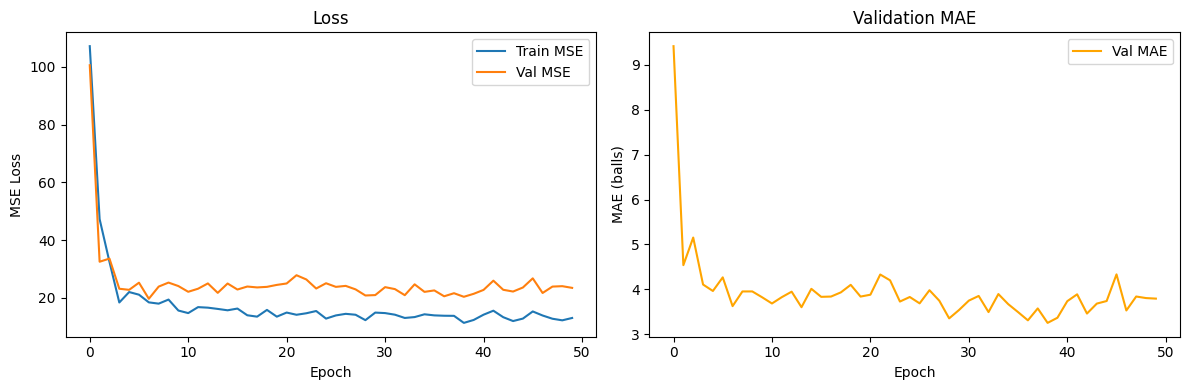

In [16]:
"""
Ball count regression using EfficientNet-B0 fine-tuning.

Pipeline:
  1. Extract ball counts from COCO JSON (exclude Dots, category_id=3)
  2. Load masked images (table cloth mask applied)
  3. Fine-tune EfficientNet-B0 with a regression head (single output)
  4. Train with MSE loss, evaluate with MAE
"""

import json
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# ── Config ────────────────────────────────────────────────────────────────────
COCO_JSON    = "8-Ball Pool/train/_annotations_labeled.coco.json"
IMAGES_DIR   = "8-Ball Pool/train"
DOT_CAT_ID   = 3
BALL_CAT_IDS = {1, 2, 4, 5}   # Black, Cue, Solid, Striped

IMG_SIZE     = 224
BATCH_SIZE   = 8
EPOCHS       = 50
LR           = 1e-3
FREEZE_BACKBONE = True        # only train the head initially
VAL_SPLIT    = 0.15
TEST_SPLIT   = 0.05
SEED         = 42

SAVE_PATH    = "ball_count_efficientnet.pth"
# ──────────────────────────────────────────────────────────────────────────────


# ── Table segmentation (from segment_table.py) ────────────────────────────────
def order_corners(corners):
    """Order corners: TL, TR, BR, BL."""
    pts = np.array(corners, dtype=np.float32)
    s   = pts.sum(axis=1)
    d   = np.diff(pts, axis=1).ravel()
    return np.array([pts[np.argmin(s)], pts[np.argmin(d)],
                     pts[np.argmax(s)], pts[np.argmax(d)]], dtype=np.float32)


def segment_table(img, erode_px=20):
    """Return (mask, corners) for the table cloth region."""
    hsv        = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    blue_mask  = cv2.inRange(hsv, np.array([90, 80, 50]),  np.array([130, 255, 255]))
    green_mask = cv2.inRange(hsv, np.array([35, 80, 50]),  np.array([85,  255, 255]))
    mask       = cv2.bitwise_or(blue_mask, green_mask)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return np.ones(img.shape[:2], dtype=np.uint8) * 255, None

    table_contour = max(contours, key=cv2.contourArea)
    epsilon       = 0.02 * cv2.arcLength(table_contour, True)
    approx        = cv2.approxPolyDP(table_contour, epsilon, True)

    if len(approx) == 4:
        corners = approx.reshape(4, 2).astype(np.float32)
    else:
        rect    = cv2.minAreaRect(table_contour)
        corners = cv2.boxPoints(rect).astype(np.float32)

    corners    = order_corners(corners)
    clean_mask = np.zeros(img.shape[:2], dtype=np.uint8)
    cv2.fillPoly(clean_mask, [corners.astype(np.int32)], 255)

    if erode_px > 0:
        kernel     = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (erode_px * 2, erode_px * 2))
        clean_mask = cv2.erode(clean_mask, kernel, iterations=1)

    return clean_mask, corners


def apply_table_mask(img):
    """Apply table mask to image, black out everything outside."""
    mask, _ = segment_table(img)
    masked   = cv2.bitwise_and(img, img, mask=mask)
    return masked
# ──────────────────────────────────────────────────────────────────────────────


def extract_labels(coco_json):
    """
    Extract ball counts per image from COCO JSON.
    Counts all annotations except Dots (category_id=3).
    Returns dict: {file_name -> count}
    """
    with open(coco_json, "r") as f:
        coco = json.load(f)

    images_by_id = {img["id"]: img["file_name"] for img in coco["images"]}

    counts = {img["file_name"]: 0 for img in coco["images"]}
    for ann in coco["annotations"]:
        if ann["category_id"] in BALL_CAT_IDS:
            fname = images_by_id[ann["image_id"]]
            counts[fname] += 1

    return counts


class BallCountDataset(Dataset):
    def __init__(self, samples, images_dir, transform=None):
        """
        samples: list of (file_name, count)
        """
        self.samples    = samples
        self.images_dir = images_dir
        self.transform  = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        fname, count = self.samples[idx]
        img_path     = os.path.join(self.images_dir, fname)

        img = cv2.imread(img_path)
        if img is None:
            # Return blank image if not found
            img = np.zeros((224, 224, 3), dtype=np.uint8)
        else:
            img = apply_table_mask(img)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transform:
            from PIL import Image
            img = self.transform(Image.fromarray(img))

        label = torch.tensor(float(count), dtype=torch.float32)
        return img, label


def build_model(freeze_backbone=True):
    """EfficientNet-B0 with regression head (single output)."""
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Replace classifier with regression head
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, 64),
        nn.ReLU(),
        nn.Linear(64, 1)
    )
    return model


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        preds = model(imgs).squeeze(1)
        loss  = criterion(preds, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(imgs)
    return total_loss / len(loader.dataset)


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_mae  = 0.0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds        = model(imgs).squeeze(1)
            total_loss  += criterion(preds, labels).item() * len(imgs)
            total_mae   += torch.abs(preds - labels).sum().item()
    n = len(loader.dataset)
    return total_loss / n, total_mae / n


def main():
    torch.manual_seed(SEED)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")

    # Build dataset
    counts  = extract_labels(COCO_JSON)
    samples = [(fname, count) for fname, count in counts.items()]
    print(f"Total samples: {len(samples)}")
    print(f"Ball count range: {min(c for _,c in samples)} - {max(c for _,c in samples)}")

    # 80/15/5 split: first extract test, then split remainder into train/val
    train_val, test_samples = train_test_split(
        samples, test_size=TEST_SPLIT, random_state=SEED
    )
    val_ratio = VAL_SPLIT / (1 - TEST_SPLIT)
    train_samples, val_samples = train_test_split(
        train_val, test_size=val_ratio, random_state=SEED
    )
    print(f"Train: {len(train_samples)}  Val: {len(val_samples)}  Test: {len(test_samples)}")

    train_tf = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    val_tf = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

    train_ds = BallCountDataset(train_samples, IMAGES_DIR, train_tf)
    val_ds   = BallCountDataset(val_samples,   IMAGES_DIR, val_tf)
    test_ds  = BallCountDataset(test_samples,  IMAGES_DIR, val_tf)
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
    val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    model     = build_model(freeze_backbone=FREEZE_BACKBONE).to(device)
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=LR
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5
    )
    criterion = nn.MSELoss()

    train_losses, val_losses, val_maes = [], [], []
    best_mae = float("inf")

    for epoch in range(1, EPOCHS + 1):
        train_loss         = train_epoch(model, train_dl, optimizer, criterion, device)
        val_loss, val_mae  = eval_epoch(model, val_dl, criterion, device)
        scheduler.step(val_loss)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_maes.append(val_mae)

        print(f"Epoch {epoch:3d}/{EPOCHS} | "
              f"Train MSE: {train_loss:.3f} | "
              f"Val MSE: {val_loss:.3f} | "
              f"Val MAE: {val_mae:.3f}")

        if val_mae < best_mae:
            best_mae = val_mae
            torch.save(model.state_dict(), SAVE_PATH)
            print(f"  -> Saved best model (MAE={best_mae:.3f})")

    print(f"\nBest Val MAE: {best_mae:.3f}")


    # Final evaluation on test set (best model)
    model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
    test_loss, test_mae = eval_epoch(model, test_dl, criterion, device)
    print(f"Test MSE: {test_loss:.3f} | Test MAE: {test_mae:.3f}")
    # Plot training curves
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(train_losses, label="Train MSE")
    ax1.plot(val_losses,   label="Val MSE")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("MSE Loss")
    ax1.legend()
    ax1.set_title("Loss")

    ax2.plot(val_maes, label="Val MAE", color="orange")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("MAE (balls)")
    ax2.legend()
    ax2.set_title("Validation MAE")

    plt.tight_layout()
    plt.savefig("training_curves.png")
    plt.show()


if __name__ == "__main__":
    main()

In [ ]:
'''import json
import os
import cv2
import numpy as np

# ── Config ───────────────────────────────────────────────────────────────────
IMG_DIR   = "8-Ball Pool/train"
JSON_PATH = os.path.join(IMG_DIR, "_annotations_clean.coco.json")
JSON_OUT  = os.path.join(IMG_DIR, "_annotations_labeled.coco.json")

# Bootstrap: if labeled file already exists resume from it, otherwise copy clean
import shutil
if not os.path.exists(JSON_OUT):
    shutil.copy2(JSON_PATH, JSON_OUT)
JSON_PATH = JSON_OUT  # all reads/writes go to the labeled file

NEEDS_LABEL = {4, 5}  # Solid, Striped
AUTO_LABEL  = {1: "black", 2: "cue"}
CAT_NAMES   = {1: "Black", 2: "Cue", 3: "Dot", 4: "Solid", 5: "Striped"}

COLORS = [
    ("yellow",  "Yellow",  (0,   190, 220)),
    ("blue",    "Blue",    (180,  80,  30)),
    ("red",     "Red",     (0,    20, 190)),
    ("purple",  "Purple",  (140,  40, 140)),
    ("orange",  "Orange",  (0,   120, 230)),
    ("green",   "Green",   (0,   100,   0)),
    ("maroon",  "Maroon",  (0,    30,  80)),
]

# Number mapping: color+type -> ball number
BALL_NUMBER = {
    ("yellow",  "solid"): 1,  ("blue",   "solid"): 2,
    ("red",     "solid"): 3,  ("purple", "solid"): 4,
    ("orange",  "solid"): 5,  ("green",  "solid"): 6,
    ("maroon",  "solid"): 7,  ("yellow", "stripe"): 9,
    ("blue",   "stripe"): 10, ("red",    "stripe"): 11,
    ("purple", "stripe"): 12, ("orange", "stripe"): 13,
    ("green",  "stripe"): 14, ("maroon", "stripe"): 15,
}

CROP_SIZE  = 220
PANEL_W    = 800
BTN_H      = 60    # button height
BTN_BAR_H  = BTN_H + 40  # total button area height
WIN_NAME   = "Ball Color Annotator"

# ── Load JSON ─────────────────────────────────────────────────────────────────
with open(JSON_PATH) as f:
    data = json.load(f)

id_to_image = {img["id"]: img for img in data["images"]}
anns_by_id  = {ann["id"]: ann for ann in data["annotations"]}

for ann in data["annotations"]:
    if ann["category_id"] in AUTO_LABEL and "ball_label" not in ann:
        ann["ball_label"] = AUTO_LABEL[ann["category_id"]]

todo  = [ann["id"] for ann in data["annotations"] if ann["category_id"] in NEEDS_LABEL]
total = len(todo)

def save_json():
    with open(JSON_PATH, "w") as f:
        json.dump(data, f, indent=2)

# ── State (mutable, shared with mouse callback) ───────────────────────────────
state = {"idx": 0, "clicked_label": None, "needs_redraw": True}

# ── Layout helpers ────────────────────────────────────────────────────────────
def compute_button_rects(frame_w, frame_h):
    """Return list of (x1,y1,x2,y2, label) for the 7 color buttons + Prev + Next."""
    rects = []
    n      = len(COLORS)
    margin = 12
    total_btn_w = frame_w - 2 * margin
    btn_w  = (total_btn_w - (n - 1) * 8) // n
    y1     = frame_h - BTN_BAR_H + 20
    y2     = y1 + BTN_H

    for i, (suffix, name, _) in enumerate(COLORS):
        x1 = margin + i * (btn_w + 8)
        x2 = x1 + btn_w
        rects.append((x1, y1, x2, y2, suffix))

    # Prev / Next nav buttons below color buttons
    nav_y1 = y2 + 8
    nav_y2 = nav_y1 + 30
    rects.append((margin,           nav_y1, margin + 100,       nav_y2, "__prev__"))
    rects.append((margin + 110,     nav_y1, margin + 210,       nav_y2, "__next__"))
    rects.append((frame_w - 160,    nav_y1, frame_w - margin,   nav_y2, "__quit__"))
    return rects

def build_frame(img_bgr, ann, frame_w, frame_h):
    cat_id  = ann["category_id"]
    bbox    = ann["bbox"]
    current = ann.get("ball_label", "")

    frame = np.zeros((frame_h, frame_w, 3), dtype=np.uint8)
    frame[:] = (25, 25, 25)

    # ── Crop (left panel) ──
    x, y, w, h = [int(float(v)) for v in bbox]
    pad = 14
    x1c = max(0, x - pad); y1c = max(0, y - pad)
    x2c = min(img_bgr.shape[1], x + w + pad)
    y2c = min(img_bgr.shape[0], y + h + pad)
    crop = img_bgr[y1c:y2c, x1c:x2c]
    crop = cv2.resize(crop, (CROP_SIZE, CROP_SIZE), interpolation=cv2.INTER_LANCZOS4)
    cy = (frame_h - BTN_BAR_H - CROP_SIZE) // 2
    frame[cy:cy + CROP_SIZE, 0:CROP_SIZE] = crop

    # Label under crop
    cv2.putText(frame, "Ball (zoomed)", (8, cy - 8),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (160, 160, 160), 1)

    # ── Original (right panel) ──
    vis = img_bgr.copy()
    cv2.rectangle(vis, (x, y), (x + w, y + h), (0, 255, 80), 3)
    scale  = PANEL_W / vis.shape[1]
    orig_h = int(vis.shape[0] * scale)
    orig   = cv2.resize(vis, (PANEL_W, orig_h))
    oy = (frame_h - BTN_BAR_H - orig_h) // 2
    frame[oy:oy + orig_h, CROP_SIZE:CROP_SIZE + PANEL_W] = orig
    cv2.putText(frame, "Original", (CROP_SIZE + 8, oy - 8),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (160, 160, 160), 1)

    # ── Progress / info ──
    labeled = sum(1 for aid in todo if "ball_label" in anns_by_id[aid])
    type_name = "SOLID" if cat_id == 4 else "STRIPED"
    info = f"{labeled}/{total} labeled   |   {type_name}   |   current: {current or 'none'}"
    cv2.putText(frame, info, (8, 22),
                cv2.FONT_HERSHEY_SIMPLEX, 0.55, (200, 200, 200), 1)

    # ── Color buttons ──
    rects = compute_button_rects(frame_w, frame_h)
    for (bx1, by1, bx2, by2, label) in rects:
        if label == "__prev__":
            cv2.rectangle(frame, (bx1, by1), (bx2, by2), (70, 70, 70), -1)
            cv2.putText(frame, "< Prev", (bx1 + 8, by2 - 8),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (220, 220, 220), 1)
        elif label == "__next__":
            cv2.rectangle(frame, (bx1, by1), (bx2, by2), (70, 70, 70), -1)
            cv2.putText(frame, "Next >", (bx1 + 8, by2 - 8),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (220, 220, 220), 1)
        elif label == "__quit__":
            cv2.rectangle(frame, (bx1, by1), (bx2, by2), (40, 40, 120), -1)
            cv2.putText(frame, "Save & Quit", (bx1 + 6, by2 - 8),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45, (220, 220, 220), 1)
        else:
            # Find color info
            color_info = next((c for c in COLORS if c[0] == label), None)
            if not color_info:
                continue
            _, name, bgr = color_info
            is_active = current and current.split("_")[1] == label if current and "_" in current else False

            cv2.rectangle(frame, (bx1, by1), (bx2, by2), bgr, -1)
            # Active highlight
            if is_active:
                cv2.rectangle(frame, (bx1 - 3, by1 - 3), (bx2 + 3, by2 + 3), (0, 255, 100), 3)
            # Button text
            brightness = int(0.299 * bgr[2] + 0.587 * bgr[1] + 0.114 * bgr[0])
            txt_color  = (0, 0, 0) if brightness > 100 else (255, 255, 255)
            tw, th = cv2.getTextSize(name, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 1)[0]
            tx = bx1 + (bx2 - bx1 - tw) // 2
            ty = by1 + (by2 - by1 + th) // 2
            cv2.putText(frame, name, (tx, ty),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55, txt_color, 1)

    return frame, rects

# ── Mouse callback ────────────────────────────────────────────────────────────
def on_mouse(event, mx, my, flags, param):
    if event != cv2.EVENT_LBUTTONDOWN:
        return
    rects, frame_shape = param
    for (bx1, by1, bx2, by2, label) in rects:
        if bx1 <= mx <= bx2 and by1 <= my <= by2:
            state["clicked_label"] = label
            break

# ── Main loop ─────────────────────────────────────────────────────────────────
def run_annotator():
    # Resume from first unlabeled
    state["idx"] = 0
    for i, ann_id in enumerate(todo):
        if "ball_label" not in anns_by_id[ann_id]:
            state["idx"] = i
            break

    cv2.namedWindow(WIN_NAME, cv2.WINDOW_NORMAL)
    frame_w = CROP_SIZE + PANEL_W
    frame_h = 700
    cv2.resizeWindow(WIN_NAME, frame_w, frame_h)

    rects = []
    cv2.setMouseCallback(WIN_NAME, on_mouse, param=[rects, (frame_h, frame_w)])

    while 0 <= state["idx"] < total:
        ann      = anns_by_id[todo[state["idx"]]]
        img_info = id_to_image[ann["image_id"]]
        img_bgr  = cv2.imread(os.path.join(IMG_DIR, img_info["file_name"]))

        frame, rects = build_frame(img_bgr, ann, frame_w, frame_h)
        # Update mouse callback param with fresh rects
        cv2.setMouseCallback(WIN_NAME, on_mouse, param=[rects, (frame_h, frame_w)])
        cv2.imshow(WIN_NAME, frame)

        # Reset click
        state["clicked_label"] = None

        # Wait for input
        while True:
            key = cv2.waitKey(30) & 0xFF

            # Keyboard shortcuts still work
            ch = chr(key).lower() if key < 128 else ""
            if ch == "p":
                state["idx"] = max(0, state["idx"] - 1); break
            elif ch == "n":
                state["idx"] = min(total - 1, state["idx"] + 1); break
            elif ch == "q" or key == 27:
                save_json(); cv2.destroyAllWindows()
                labeled = sum(1 for aid in todo if "ball_label" in anns_by_id[aid])
                print(f"Saved. {labeled}/{total} labeled.")
                return

            # Mouse click handled
            if state["clicked_label"]:
                label = state["clicked_label"]
                state["clicked_label"] = None

                if label == "__prev__":
                    state["idx"] = max(0, state["idx"] - 1); break
                elif label == "__next__":
                    state["idx"] = min(total - 1, state["idx"] + 1); break
                elif label == "__quit__":
                    save_json(); cv2.destroyAllWindows()
                    labeled = sum(1 for aid in todo if "ball_label" in anns_by_id[aid])
                    print(f"Saved. {labeled}/{total} labeled.")
                    return
                else:
                    # Color button clicked
                    type_suffix = "solid" if ann["category_id"] == 4 else "stripe"
                    num = BALL_NUMBER.get((label, type_suffix), 0)
                    ann["ball_label"] = f"{num}_{label}_{type_suffix}"
                    save_json()
                    state["idx"] += 1
                    break

    save_json()
    cv2.destroyAllWindows()
    labeled = sum(1 for aid in todo if "ball_label" in anns_by_id[aid])
    print(f"Done. {labeled}/{total} labeled.")

run_annotator()
'''

Saved. 1762/1762 labeled.
